# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 6 - Stationary vs. Non-stationary Time Series


A critical aspect of analyzing time series data is understanding its stationarity, as many statistical methods and models assume stationarity. Non-stationary data can lead to inaccurate results, while stationary analysis simplifies complexity and improves interpretability.


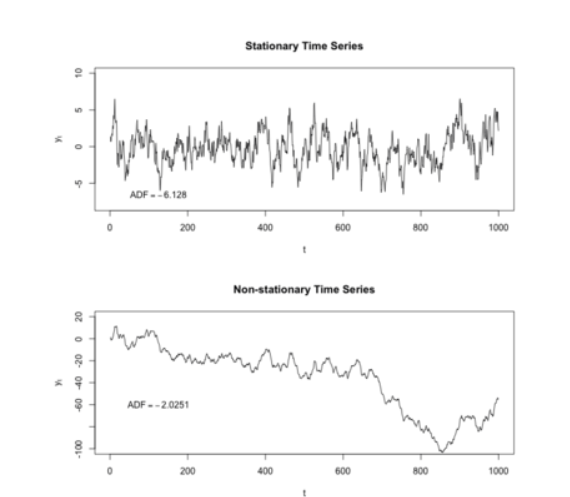

A stationary time series is a type of time series whose statistical properties do not change over time. This means that the statistical behavior of the process remains constant regardless of when the observations were recorded.

Intuitively, this means that if we were to take a snapshot of the time series at any point in time, the statistical properties of that snapshot would be similar to those of any other snapshot taken at a different point in time. For example, the mean and variance of the time series would be identical, and the correlation between observations would depend only on the time difference between them, not on the absolute time at which they were recorded.

Technically, a stationary time series is defined as a stochastic process whose joint distribution is shift invariant. This means that the joint distribution of the process remains the same no matter how much we shift the time axis. In other words, the statistical properties of the process do not change over time.

We can look for specific characteristics in the data to determine whether a time series is stationary or non-stationary. For example, a stationary time series will have a constant mean, variance, and autocorrelation over time. On the other hand, non-stationary time series may exhibit trends, seasonality, or variance variation.


## How to check stationarity?


There are two ways to test a time series for stationarity:

- Intuitive approach: Visual assessment;
- Statistical approach: Unit root tests.


### Intuitive Approach


You can visually assess the stationarity of a time series by mentally dividing the time series in half and comparing the mean, amplitude, and cycle length of the first half with the second half of the time series.

- Constant mean - The mean value of the first half of the time series should be similar to that of the second half.
- Constant variance - The amplitude of the first half of the time series should be similar to that of the second half.
- Time-independent covariance - The cycle length in the first half of the time series should be similar to that of the second half. Cycles should be time-independent (e.g., they should not be weekly or monthly, etc.).


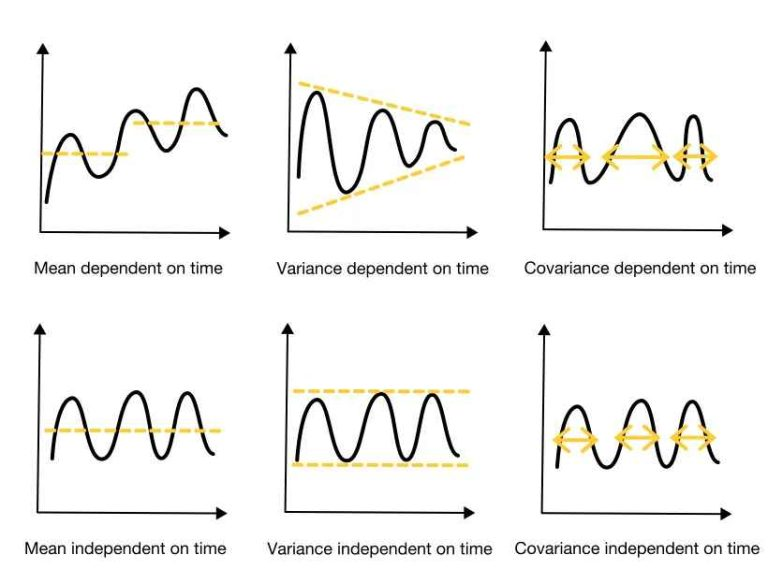

### Statistical approach


The unit root is a property of time series that indicates the presence of a root of the characteristic equation equal to 1, which can lead to non-stationary behavior of the time series. In simpler terms, the presence of a unit root suggests that the time series is not stationary or that its mean and variance change over time. It is possible to assess whether there is a unit root in a series by means of two tests.


A unit root is a stochastic trend, i.e. a random walk with drift. Since random behavior cannot be predicted, this means:

- Presence of unit root: non-stationary (unpredictable);
- Absence of unit root: stationary.

To test stationarity, it is necessary to use a unit root test, and therefore, it is necessary to create competing hypotheses:

- Null hypothesis (H0) - for example, the time series is stationary (no unit root present);
- Alternative hypothesis (H1) - for example, the time series is not stationary (unit root present).

You will assess whether to reject or fail to reject the null hypothesis based on two approaches:

- P-value: If the p-value > 0.05, fail to reject the null hypothesis. If the p-value ≤ 0.05, reject the null hypothesis;
- Critical value: If the test statistic is less than the critical value, fail to reject the null hypothesis. If the test statistic is greater than the critical value, reject the null hypothesis. The critical value approach should be used when the p-value is close to being significant (e.g. around 0.05).

There are several unit root tests that you can use to check for stationarity.

Let's start by importing the Drive and getting our file that contains a time series of temperature data:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Link to the dataset: https://drive.google.com/file/d/10omy6A3pjEAbQzISjglvSkpiCpBpx3A_/view?usp=sharing

In [ ]:
path = '/content/drive/MyDrive/Datasets_TS/Global Temperature.csv'

In [ ]:
df = pd.read_csv(path)

In [ ]:
df.head()

,Year,Month,Monthly Anomaly,Monthly Unc.,Annual Anomaly,Annual Unc,Five-Year Anomaly,Five-Year Unc.,Ten-Year Anomaly,Ten-Year Unc.,Twenty-Year Anomaly,Twenty-year Unc.
0,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.485,0.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.351,0.549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's create the variable with day, month and year:


In [ ]:
df.rename(columns={' Month': 'Month'}, inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df.Year.astype(str) + '/' + df.Month.astype(str) + '/01')

In [ ]:
df

,Year,Month,Monthly Anomaly,Monthly Unc.,Annual Anomaly,Annual Unc,Five-Year Anomaly,Five-Year Unc.,Ten-Year Anomaly,Ten-Year Unc.,Twenty-Year Anomaly,Twenty-year Unc.,Date
0,1850,1,-0.801,0.482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-01-01
1,1850,2,-0.102,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-02-01
2,1850,3,-0.119,0.819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-03-01
3,1850,4,-0.485,0.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-04-01
4,1850,5,-0.351,0.549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2072,2022,9,0.971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-01
2073,2022,10,1.126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-01
2074,2022,11,0.626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-01
2075,2022,12,0.923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-01


We will work with the monthly anomaly:


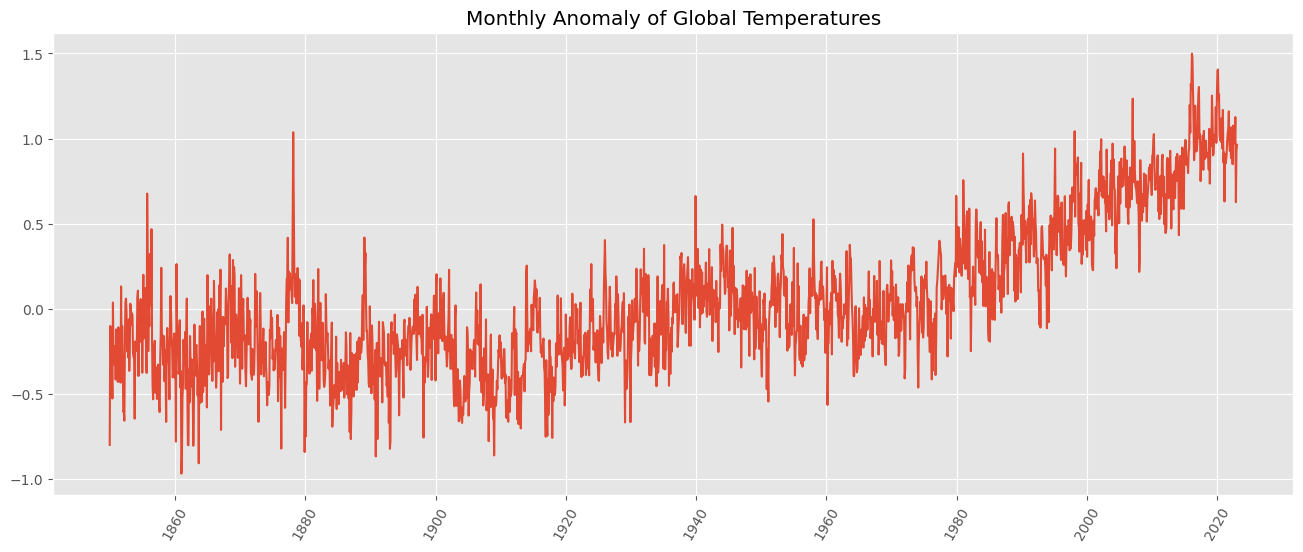

In [ ]:
plt.figure(figsize=(16,6))
plt.style.use("ggplot")
plt.plot(df.Date, df['Monthly Anomaly'])
plt.title('Monthly Anomaly of Global Temperatures')
plt.xticks(rotation=60)
plt.show()

In [ ]:
df.set_index('Date', inplace=True)

## Augmented Dickey-Fuller Test


The ADF test is used to determine the presence of a unit root in a series, and therefore, to verify whether the series is stationary or not.

In the test, the null hypothesis and the alternative hypothesis are:

- Null Hypothesis: the series contains a unit root
- Alternative Hypothesis: the series does not contain a unit root
If we do not reject the null hypothesis, the test shows that the series is not stationary.


In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [ ]:
adf_test(df['Monthly Anomaly'])

Results of Dickey-Fuller Test:
Test Statistic                   -1.350073
p-value                           0.605964
#Lags Used                       23.000000
Number of Observations Used    2053.000000
Critical Value (1%)              -3.433539
Critical Value (5%)              -2.862949
Critical Value (10%)             -2.567520
dtype: float64


The statsmodels package provides a reliable implementation of the ADF test through the adfuller() function in statsmodels.tsa.stattools. It returns the following outputs:

- The p-value
- The value of the test statistic
- The number of lags considered for the test
- The critical value cutoffs.

When the test statistic is less than the critical value shown, you reject the null hypothesis and infer that the time series is stationary.

As seen previously, the null hypothesis of the test is the presence of a unit root; that is, the series is not stationary.


ADF tests provide the following results – test statistic, p-value, and critical value at 1%, 5%, and 10% confidence intervals.


The test statistic is -1.350073, which is greater than either of the critical values.

The ADF statistic is greater than either of the critical values. Clearly, there is no reason to reject the null hypothesis. Therefore, the time series is indeed non-stationary.


## Kwiatkowski-Phillips-Schmidt-Shin (“KPSS”)

KPSS is another test to check if the series is stationary. The KPSS hypotheses are the opposite of ADF, that is:

- Null Hypothesis: the series does not contain a unit root
- Alternative Hypothesis: the series contains a unit root
If we do not reject the alternative hypothesis, the test shows that the series is not stationary.

In [ ]:
from statsmodels.tsa.stattools import kpss

In [ ]:
def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','#Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

In [ ]:
kpss_test(df['Monthly Anomaly'])

Results of KPSS Test:
Test Statistic            5.409595
p-value                   0.010000
#Lags Used               27.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


<ipython-input-15-aec3ac3c5ed4>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression='c', nlags="auto")


The KPSS test output contains 4 things:

- The KPSS statistic
- p-value
- Number of lags used by the test
- Critical values

The p-value reported by the test is the probability score based on which you can decide whether or not to reject the null hypothesis. If the p-value is less than a predefined alpha level (typically 0.05), then we reject the null hypothesis.

The KPSS statistic is the actual test statistic that is computed during the test run.

To reject the null hypothesis, the test statistic must be greater than the given critical values. If it is, in fact, greater than the target critical value, then this should automatically reflect in a low p-value. That is, if the p-value is less than 0.05, then the kpss statistic will be greater than the 5% critical value.

### Combining Results

It is always suggested to apply both tests to the series, so that it can be confirmed with complete certainty that the series are really stationary. There are also possible test results:

- Case 1: Both tests conclude that the series is not stationary - The series is not stationary
- Case 2: Both tests conclude that the series is stationary - The series is stationary
- Case 3: KPSS indicates stationarity, and ADF indicates non-stationarity. The series has a stationary trend, therefore, it is necessary to remove the trend so that the series is strictly stationary. Check whether the new series is stationary.
- Case 4: KPSS indicates non-stationarity and ADF indicates stationarity. The series is stationary in the difference, that is, it is necessary to differentiate the series so that it is stationary. Check whether the new series is stationary.

# Differencing

The process of calculating the differences between successive observations in a given time series is known as differencing. Higher-order differences can be obtained by further differencing the resulting series, which is called first differencing.

The main purpose of differencing is to remove non-constant variations and trends from a time series, while stabilizing the mean. When working with non-stationary data — where the statistical characteristics of the series fluctuate over time.

Differences are used in time series analysis to adjust the mean and remove trends or time lags in data. The idea is to calculate the difference between a series of observations at time intervals, resulting in a new series of data points that represent changes from one period to another rather than absolute values. Differences are useful when dealing with non-stationary time series data, where the mean, variance, or other statistical characteristics change over time. Observing and analyzing non-stationary data can be more complicated, and differencing is a common method of converting this information into a stable form. Each value in the time series is subtracted from the previous value in first-order differencing.

As a result, a new series is created that symbolizes the transition from one era to the next. Subtracting the second-lag value from the present value is the higher-order differencing process, and so on.

The basic idea of ​​differencing is to take differences between successive occurrences of the time series Δxt = xt - xt-1 such that Δxt has constant mean and variance and hence can be treated as a stationary series.

In [ ]:
diff_data = df['Monthly Anomaly'].diff()

In [ ]:
diff_data

,Monthly Anomaly
Date,
1850-01-01,NaN
1850-02-01,0.699
1850-03-01,-0.017
1850-04-01,-0.366
1850-05-01,0.134
...,...
2022-09-01,-0.068
2022-10-01,0.155
2022-11-01,-0.500


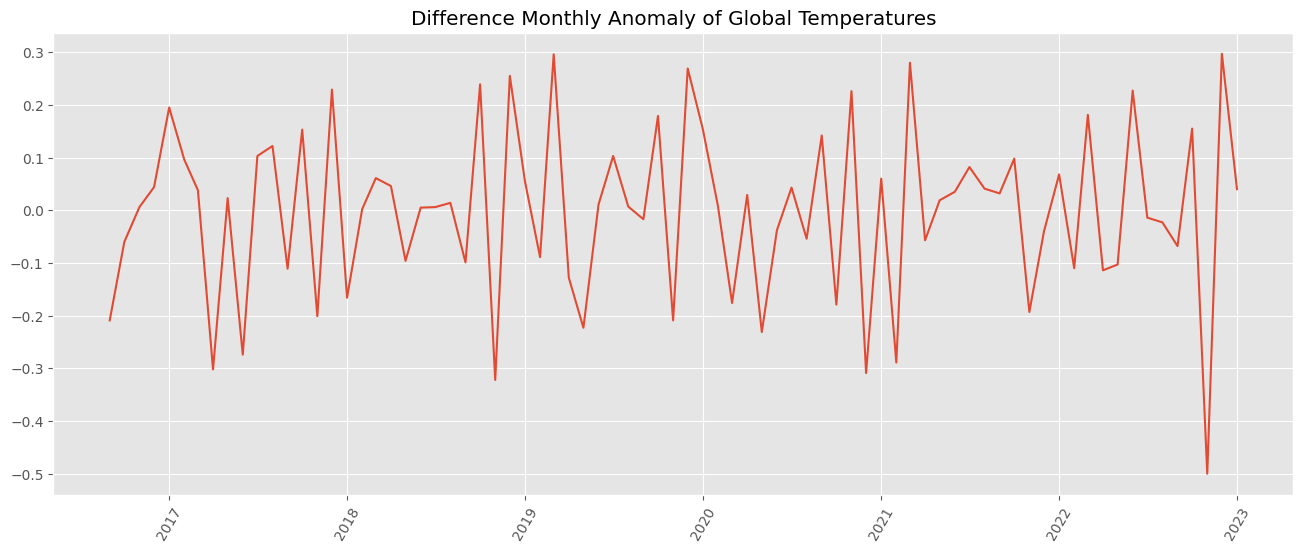

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(diff_data[2000:])
plt.title('Difference Monthly Anomaly of Global Temperatures')
plt.xticks(rotation=60)
plt.show()

Let's apply the difference of 12:

In [ ]:
seasonal_diff = diff_data.diff(12)

In [ ]:
seasonal_diff

,Monthly Anomaly
Date,
1850-01-01,NaN
1850-02-01,NaN
1850-03-01,NaN
1850-04-01,NaN
1850-05-01,NaN
...,...
2022-09-01,-0.100
2022-10-01,0.057
2022-11-01,-0.307


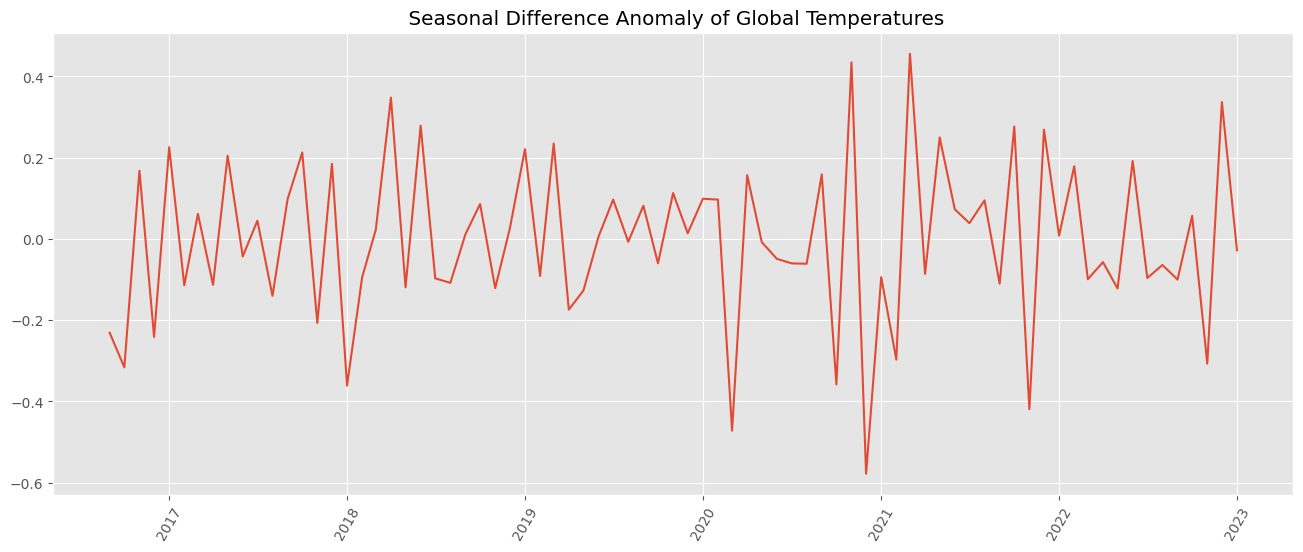

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(seasonal_diff[2000:])
plt.title(' Seasonal Difference Anomaly of Global Temperatures')
plt.xticks(rotation=60)
plt.show()

### Choosing the Appropriate Seasonal Differentiation Order

The appropriate differencing order depends on factors specific to your time series data, such as:

- Trend: How strong is the trend? First-order differencing will be sufficient to remove it.
- Seasonality: Do the data exhibit seasonal patterns? Second-order differencing will be necessary to do this.
- Noise: How much noise is present in the data? Higher orders of differencing can amplify the noise.

# Internal structures of time series

Now let us look at the following special features of time series data that require their special mathematical treatment:

- General trend
- Seasonality
- Cyclical movements
- Unexpected variations

Most time series have one or more of the internal structures mentioned above. Based on this notion, a time series can be expressed as xt = ft + st + ct + et, which is a sum of the trend, seasonal, cyclical and irregular components in that order. Here, t is the time index at which observations on the series were made at t = 1,2,3...N successive and equally spaced points in time.

The goal of time series analysis is to decompose a time series into its constituent features and develop mathematical models for each. These models are then used to understand what causes the observed behavior of the time series and to forecast the series for future points in time.

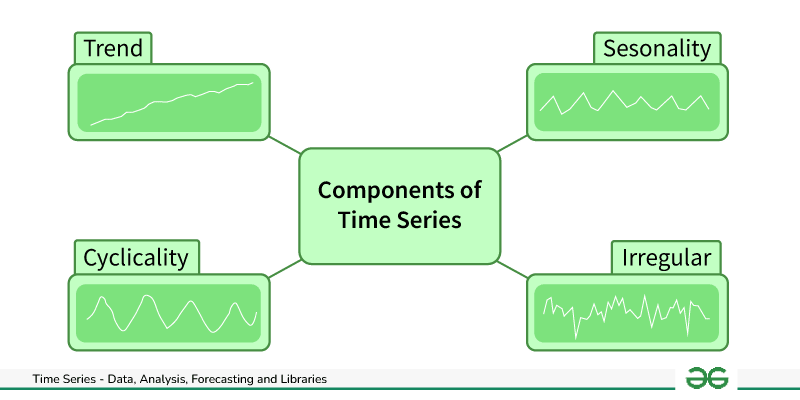

Trends show the general direction of data and whether it is increasing, decreasing, or remaining stationary over a long period of time. Trends indicate long-term movement in data and can reveal overall growth or decline. For example, e-commerce sales may show an upward trend over the past five years.


Seasonality refers to predictable patterns that repeat regularly, such as annual retail spikes during the holiday season. Seasonal components exhibit fixed fluctuations in time, direction, and magnitude. For example, electricity usage may increase each summer as people turn on their air conditioners.


Cycles demonstrate fluctuations that do not have a fixed period, such as economic expansions and recessions. These long-term patterns last more than a year and do not have consistent amplitudes or durations. Business cycles that oscillate between growth and decline are an example.


Finally, noise encompasses the residual variability in the data that the other components cannot explain. Noise includes unpredictable and erratic deviations after accounting for trends, seasonality, and cycles.

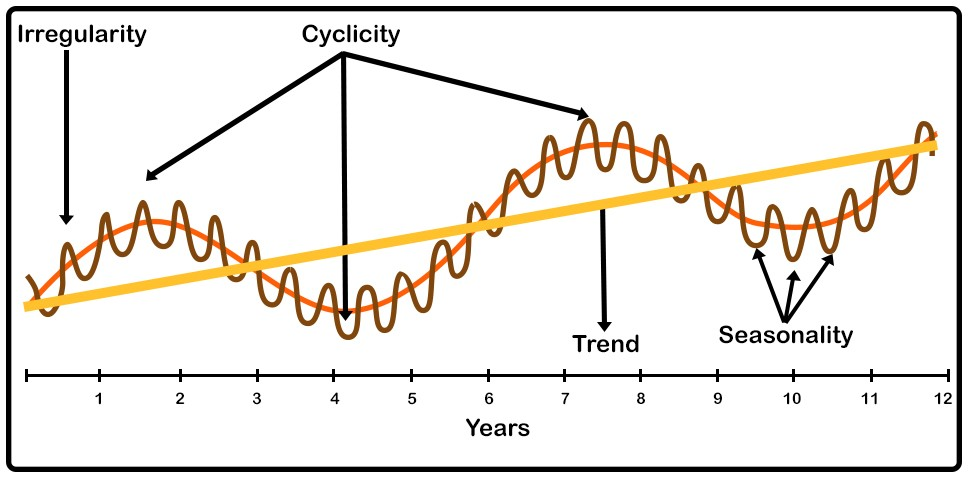

## Models for time series analysis


The purpose of time series analysis is to develop a mathematical model that can explain the observed behavior of a time series and possibly predict the future state of the series. The chosen model should be able to explain one or more of the internal structures that may be present. Therefore, we will give an overview of the following general models that are often used as building blocks of time series analysis:

- Zero mean models
- Random walk
- Trend models
- Seasonality models

### Zero mean models

Zero-mean models have a constant mean and constant variance and do not show predictable trends or seasonality. Observations from a zero-mean model are assumed to be independent and identically distributed (iid) and represent random noise around a fixed mean, which has been inferred from the time series as a constant term.

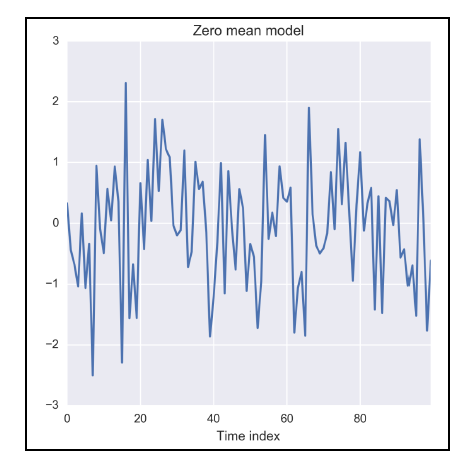

### Random walk

A random walk is given as a sum of n iids, which have zero mean and constant variance. Based on this definition, the performance of a random walk at time index t is given by the sum S = x1 + x2 + ... + xn. Random walk is important because if such behavior is found in a time series, it can be easily reduced to a zero mean model by taking differences of the observations from two consecutive time indices as St - St-1 = xt is an iid with zero mean and constant variance.

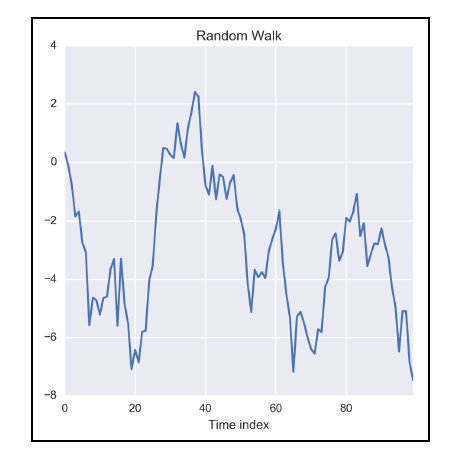

### Trend models

This type of model aims to capture the long-term trend in the time series which can be fitted as linear regression of the time index. When the time series does not exhibit any periodic or seasonal fluctuations, it can be expressed as just the sum of the trend and the zero-mean model as xt = μ(t) + yt, where μ(t) is the time-dependent long-term trend of the series.

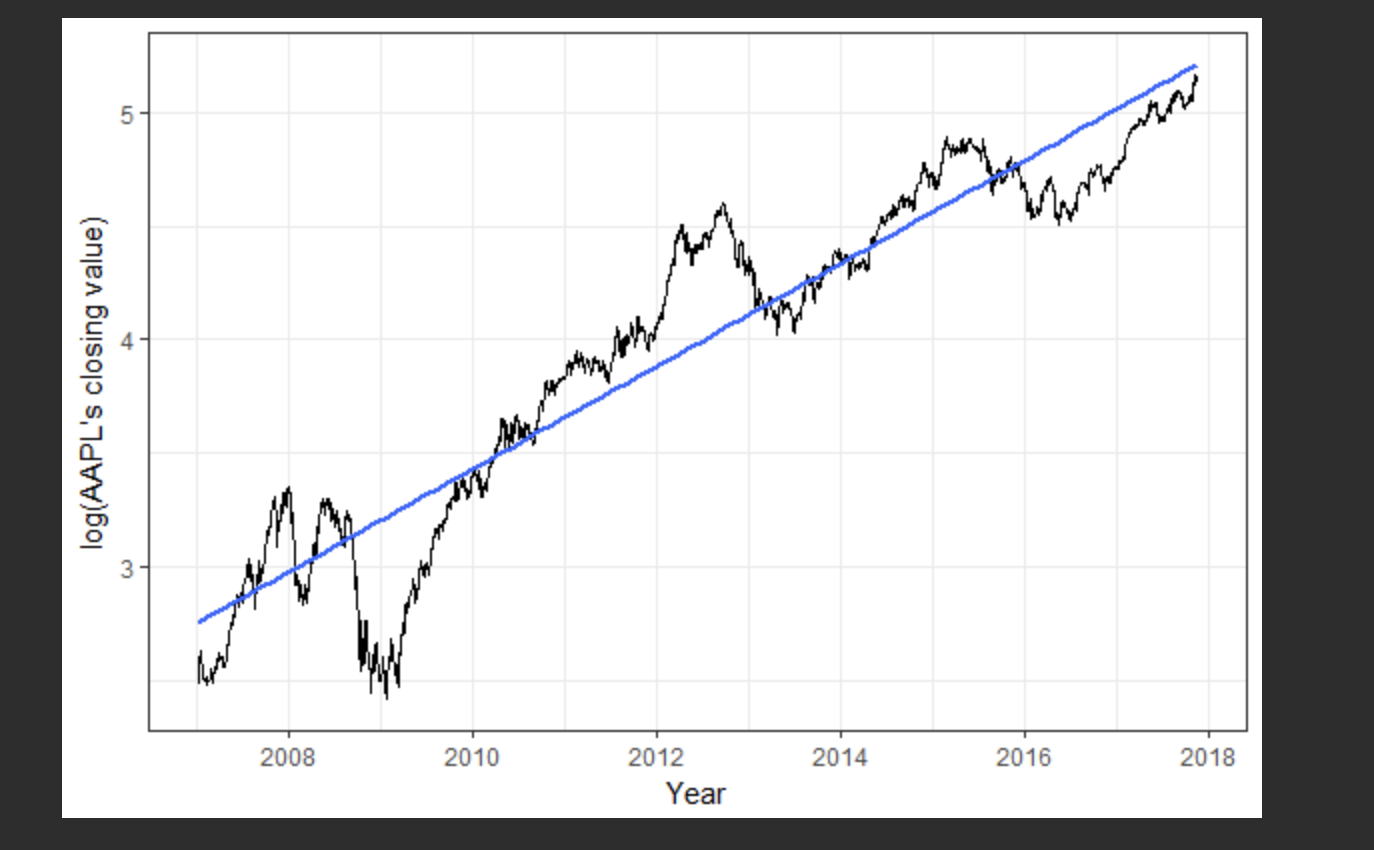

### Seasonality models

Seasonality manifests itself as periodic and repetitive fluctuations in a time series and is therefore modeled as a sum of weighted summation of sine waves of known periodicity. Seasonality models are also known as harmonic regression models, as they attempt to fit the summation of multiple sine waves.

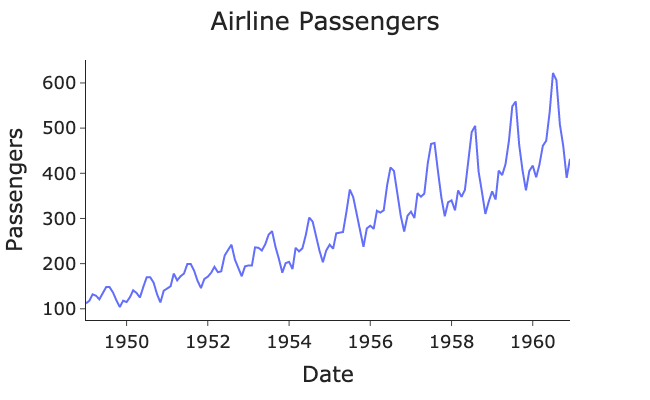

# Autocorrelation and partial autocorrelation

Autocorrelation is the correlation between two observations at different points in a time series. For example, values ​​separated by an interval may have a strong positive or negative correlation. When these correlations are present, they indicate that past values ​​influence the current value. Analysts use the autocorrelation and partial autocorrelation functions to understand the properties of time series data, fit appropriate models, and make predictions.

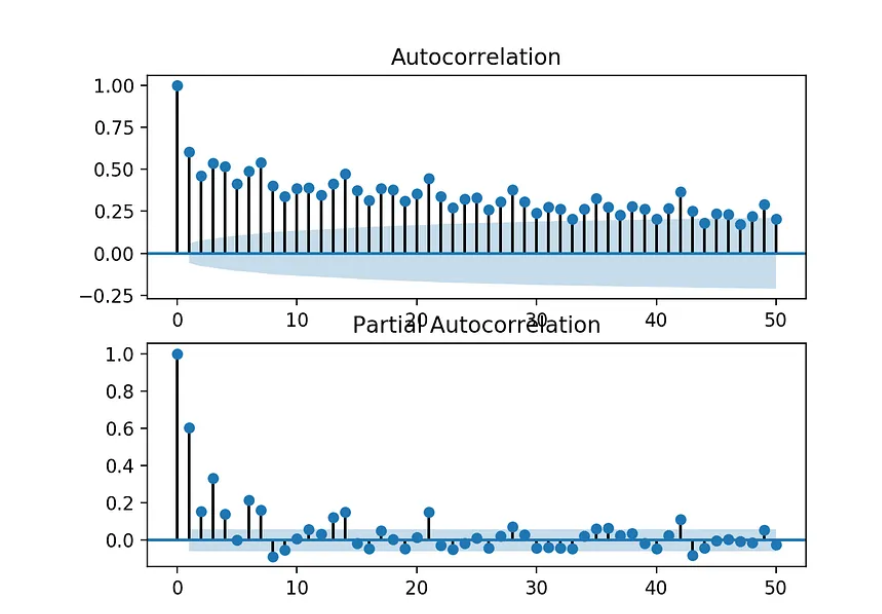

Autocorrelation is the correlation between two values ​​in a time series. In other words, the data in the time series correlate with each other—hence the name. We talk about these correlations using the term “lags.” Analysts record time series data by measuring a characteristic at evenly spaced intervals—such as daily, monthly, or yearly. The number of intervals between the two observations is the lag. For example, the lag between the current observation and the previous one is one. If you go back one more interval, the lag is two, and so on.

In mathematical terms, the observations in yt and yt–k are separated by k time units. K is the lag. This lag can be days, quarters, or years, depending on the nature of the data. When k=1, you are evaluating adjacent observations. For each lag, there is a correlation.

Let's access our example dataset:

Link to the dataset: https://drive.google.com/file/d/15j6VsL8OJVFQo-KFI4HK3Qw-k-tzRAF6/view?usp=sharing

In [ ]:
path = '/content/drive/MyDrive/Datasets_TS/data_et0.csv'

In [ ]:
data = pd.read_csv(path)

In [ ]:
data

,Year,Month,Date,ET0_mm,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1990,1,1990-02-01,229.1,NaN,NaN,NaN
1,1990,2,1990-03-04,155.9,NaN,NaN,NaN
2,1990,3,1990-04-04,167.9,NaN,NaN,NaN
3,1990,4,1990-05-05,81.3,NaN,NaN,NaN
4,1990,5,1990-06-05,40.9,NaN,NaN,NaN
...,...,...,...,...,...,...,...
367,2020,8,2020-09-05,51.4,NaN,NaN,NaN
368,2020,9,2020-10-06,80.8,NaN,NaN,NaN
369,2020,10,2020-11-06,137.4,NaN,NaN,NaN
370,2020,11,2020-12-07,213.4,NaN,NaN,NaN


In [ ]:
data = data.drop(columns=['Year', 'Month', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'])

## Autocorrelation Function (ACF)

The autocorrelation function (ACF) plots the correlation coefficient against the lag, and is a visual representation of autocorrelation.

For example, the ACF at lag 3 is calculated as the correlation between the time series (Yt) and the same time series lagged by 3 time periods (Yt-3). In this way, the correlation is estimated at each lag and plotted on a graph that shows the correlation coefficient at each lag.

The correlation coefficient is measured by the Pearson correlation coefficient or the Spearman rank correlation coefficient.

The correlation coefficient can range from -1 (a perfect negative relationship) to +1 (a perfect positive relationship). A coefficient of 0 means that there is no relationship between the variables.

The autocorrelation function starts at lag 0, which is the correlation of the time series with itself and therefore results in a correlation of 1.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

<Axes: >

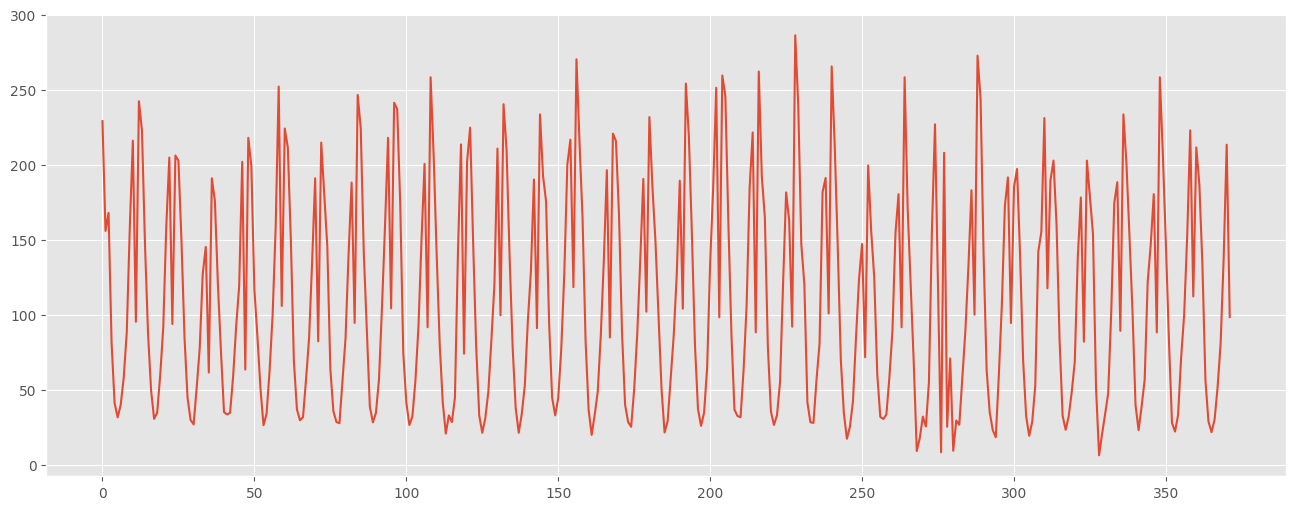

In [ ]:
plt.figure(figsize=(16,6))
data['ET0_mm'].plot()

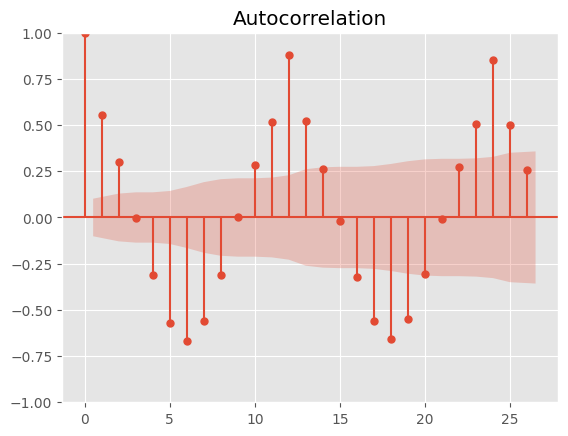

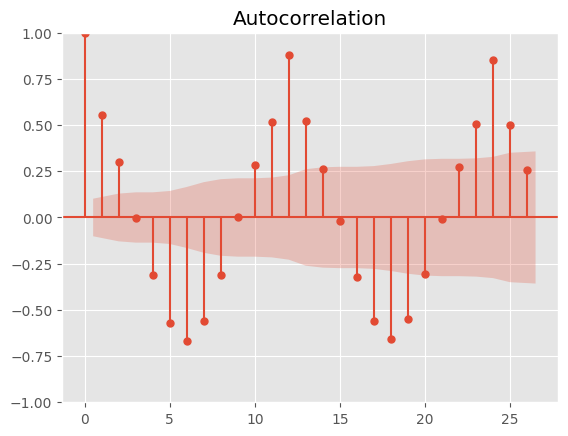

In [ ]:
plot_acf(data['ET0_mm'])

## Autocorrelation for different time series models

- Randomness: For random data, autocorrelations should be close to zero for all lags. Analysts also refer to this condition as white noise. Non-random data has at least one significant lag. When data is non-random, it is a good indication that you need to use time series analysis or incorporate lags into a regression analysis to model the data properly.

- Stationarity: Stationarity means that the time series does not have a trend, has a constant variance, a constant autocorrelation pattern, and no seasonal pattern. The autocorrelation function declines to near zero quickly for a stationary time series. In contrast, the ACF declines slowly for a non-stationary time series.

- Trends: When trends are present in a time series, shorter lags usually have large positive correlations because observations closer together in time tend to have similar values. Correlations slowly decrease as lags increase.

- Seasonality: When seasonal patterns are present, autocorrelations are larger for lags at multiples of the seasonal frequency than for other lags. When a time series has both a trend and seasonality, the ACF plot displays a mixture of both effects.

## Partial autocorrelation function (PACF)

A partial autocorrelation function captures a direct correlation between a time series and a lagged version of itself.

For example, if we are regressing a signal S at lag t (St) with the same signal at lags t-1, t-2, and t-3 (St-1, St-2, St-3), the partial correlation between St and St-2 is the amount of correlation between St and St-3 that is not explained by their mutual correlations with St-1 and St-2.

The PACF plot is constructed by plotting all the PACF values ​​obtained from regressions at different lags.

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

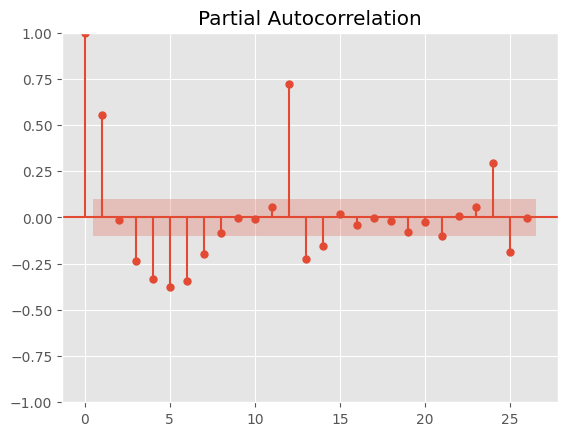

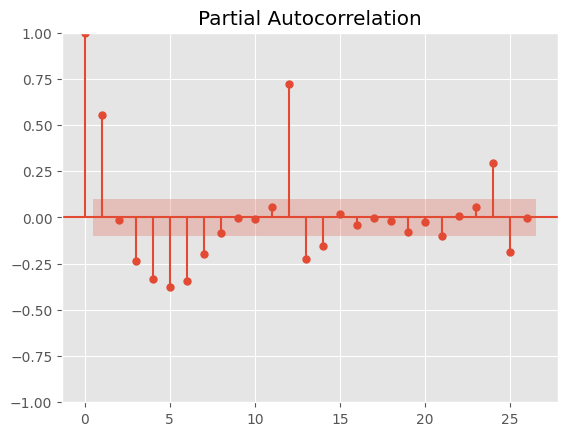

In [ ]:
plot_pacf(data['ET0_mm'])

## Importance of ACF and PACF

The ACF and PACF plots are used to find out the order of the AR and MA components of an ARIMA model.

If the ACF plot is declining and there are some significant lags in the PACF, it indicates that the process is AR (autoregressive). We can select the order p for the AR(p) model based on significant peaks in the PACF plot. The peaks that lie outside the blue boundary of the PACF plot tell us the order of the AR model.

If the PACF plot is declining and there are some significant lags in the ACF, it indicates that the process is MA (moving average). We can select the order q for the MA(q) model based on significant peaks in the ACF plot. The peaks that lie outside the blue boundary of the ACF plot tell us the order of the MA model.

The blue area in the ACF and PACF plots indicated a 95% confidence interval and is an indicator of the significance threshold. Anything within the area is statistically close to zero and anything outside is statistically different from zero.

To determine the order of the model, we have to consider the peaks that are outside the significance limit (blue area).

# Time series decomposition

Time series data consists of observations made at consecutive points in time. This data can often be decomposed into multiple components to better understand the underlying patterns and trends. Time series decomposition is the process of separating a time series into its constituent components, such as trend, seasonality, and noise. In this article, we will explore various time series decomposition techniques, their types, and provide code samples for each.



Time series decomposition helps us divide a time series dataset into three main components:

- Trend: The trend component represents the long-term movement in the data, representing the underlying pattern.

- Seasonality: The seasonality component represents the repeated short-term fluctuations caused by factors such as seasons or cycles.

- Residual (noise): The residual component represents the random variability that remains after the trend and seasonality are removed.

By separating these components, we can gain insights into the behavior of the data and make better predictions.

## Types of time series decomposition

### Additive Decomposition:

In additive decomposition, the time series is expressed as the sum of its components: Y(t) = Trend(t) + Seasonal(t) + Residual(t)

It is suitable when the magnitude of seasonality does not vary with the magnitude of the time series.

### Multiplicative decomposition:

In multiplicative decomposition, the time series is expressed as the product of its components: Y(t) = Trend(t) * Seasonal(t) * Residual(t)

It is suitable when the magnitude of seasonality scales with the magnitude of the time series.

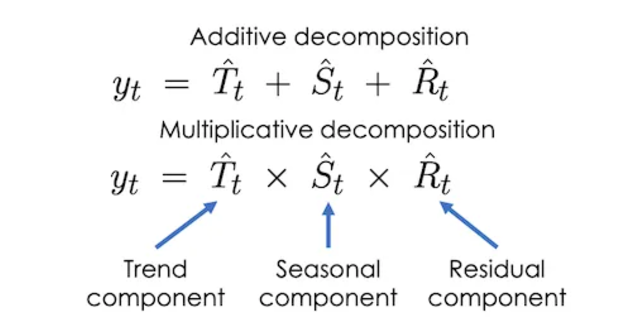

But why would you decompose a time series? Time series decomposition is used in time series analysis for tasks such as:

- exploratory data analysis (e.g., did unemployment increase this quarter after adjusting for seasonality?);
- preprocessing time series to identify and impute outliers and missing data;
- extracting features from time series for later use in classification, regression, and forecasting tasks;
- building forecasts (e.g., components can be forecasted separately and then aggregated to produce the final forecast).

In [ ]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

We will authenticate and initialize the project in GEE:

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

We select an area and start and end date:

In [ ]:
amazonia_roi = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'Brazil'))
date_start = '2022-01-01'
date_end = '2022-08-30'

Let's get the fire spots from FIRMS:

In [ ]:
firms = ee.ImageCollection('FIRMS').filterDate(date_start, date_end).filterBounds(amazonia_roi)
firms = firms.select(['T21'])

    # Calculate mean for the selected bands within the point region
def reduce_region_function(image):
    reduced_data = image.reduceRegion(reducer=ee.Reducer.count(), geometry=amazonia_roi, scale=1000)
    return image.set(reduced_data).set('system:time_start', image.get('system:time_start'))

firms = firms.map(reduce_region_function)

In [ ]:
firms_count = np.array(firms.aggregate_array("T21").getInfo())

We will convert the data to a dataframe:

In [ ]:
dates = np.array(firms.aggregate_array("system:time_start").getInfo())
day = [datetime.datetime.fromtimestamp(i/1000).strftime('%Y-%m-%d') for i in (dates)]

In [ ]:
firms_df = pd.DataFrame(firms_count, index = day, columns = ['Fires'])

In [ ]:
firms_df['Fires'] = firms_df['Fires'].astype(int)

In [ ]:
firms_df

In [ ]:
firms_df.index = pd.to_datetime(firms_df.index)

We can present the data and analyze our time series:

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(firms_df.index, firms_df['Fires'], label='Fires')
plt.xlabel('Date')
plt.ylabel('Fires counting')
plt.title('FIRMS fires counting Time Series - Amazonia')
plt.legend()
plt.show()

Let's apply the stationarity test:

In [ ]:
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [ ]:
adf_test(firms_df['Fires'])

After checking the stationarity, let's decompose our time series:

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
result_add = seasonal_decompose(firms_df['Fires'], model='additive')

In [ ]:
plt.figure(figsize=(9, 3))

plt.plot(result_add.trend, label='Additive Trend')
plt.legend()

In [ ]:
plt.figure(figsize=(9, 3))

plt.plot(result_add.seasonal, label='Additive Seasonal')
plt.legend()

In [ ]:
plt.figure(figsize=(9, 3))
plt.plot(result_add.resid, label='Additive Residuals', marker='o', linestyle='None')
plt.legend()
plt.show()

We can visualize everything in a single figure:

In [ ]:
decompose_model = seasonal_decompose(firms_df['Fires'], model='multiplicative', period=30)

In [ ]:
decompose_model.plot()

## Time series decomposition with LOESS

The goal of STL is to extract a single seasonal component, a trend component, and a residual component from a time series. It does this by applying Loess to multiple transformations of the original time series and recursively extracting the trend and seasonal component.

STL calculates the seasonal component using Loess. Therefore, there is a parameter in STL for a window size and polynomial degree associated with the seasonal component. A summary of STL's seasonal parameters are therefore:

- period: The period of the seasonal component we want STL to extract (e.g. period=12 if we want annual seasonality and the data frequency is monthly);
- seasonal: The Loess window size used to extract the seasonal component in STL (this determines how smooth and regular the extracted seasonal component is);
- seasonal_deg: The polynomial degree used by Loess to extract the seasonal component in STL (typically set to 0 or 1).

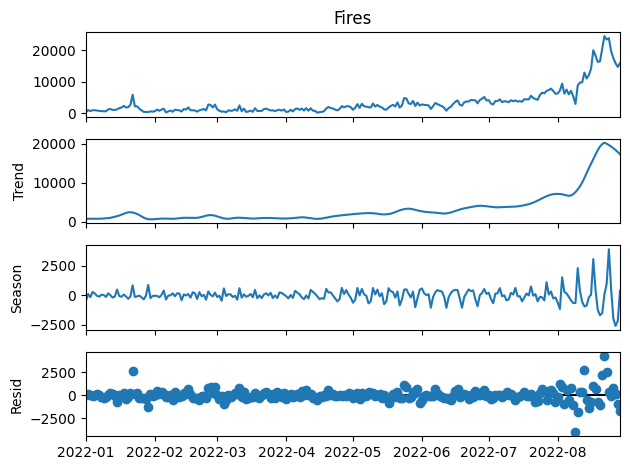

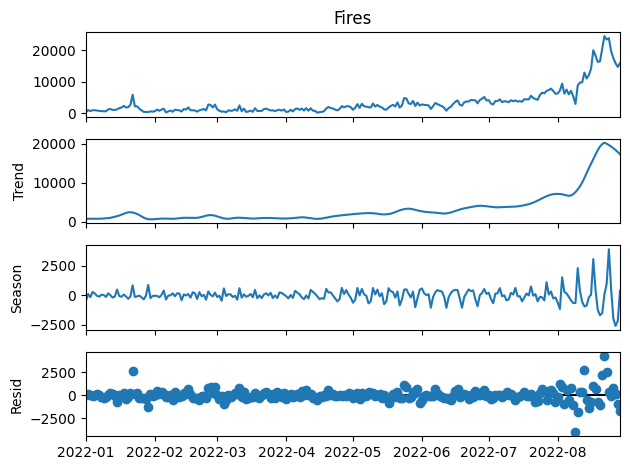

In [ ]:
from statsmodels.tsa.seasonal import STL

stl_decomposition = STL(firms_df['Fires']).fit()
stl_decomposition.plot()

Time series decomposition is a powerful technique for analyzing geospatial data because it allows you to separate out the different components that influence the observed variations over time, such as trend, seasonality, and noise. This approach makes it easier to identify underlying patterns, such as long-term changes in land use or seasonal variations in climate indices, that might otherwise be obscured in global analyses. In addition, decomposition allows you to address the inherent complexity of geospatial data, where local and regional variations can significantly impact results. This allows analysts to generate more accurate insights and make decisions based on specific aspects of each component.

Another advantage of decomposition is improved modeling and forecasting. By separating the components of a time series, predictive models can be adjusted more efficiently for each one, resulting in greater accuracy. For example, trend can be modeled with regression techniques, while seasonality can be treated with periodic models. This is especially useful in geospatial data applied to environmental, meteorological or economic studies, where spatial and temporal interactions play a critical role. Thus, decomposition not only facilitates data interpretation but also improves the performance of future analyses.

## Thank you! See you in the next Chapter!

References:

https://www.timescale.com/learn/stationary-time-series-analysis

https://towardsdatascience.com/stationarity-in-time-series-analysis-90c94f27322

https://otexts.com/fpp2/stationarity.html

https://machinelearningmastery.com/gentle-introduction-random-walk-times-series-forecasting-python/

https://www.analyticsvidhya.com/blog/2021/06/statistical-tests-to-check-stationarity-in-time-series-part-1/

https://analisemacro.com.br/data-science/python/estacionariedade_series_temporais/

https://www.geeksforgeeks.org/seasonal-adjustment-and-differencing-in-time-series/

https://forecastegy.com/posts/differencing-time-series-in-python-with-pandas-numpy-and-polars/

https://towardsdatascience.com/multi-seasonal-time-series-decomposition-using-mstl-in-python-136630e67530

https://www.pyquantnews.com/the-pyquant-newsletter/forecasting-time-series-with-decomposition

https://www.geeksforgeeks.org/time-series-decomposition-techniques/